In [94]:
import pandas as pd 
import numpy as numpy

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

import joblib



from sklearn.ensemble import VotingRegressor

In [64]:
white=pd.read_csv('winequality-white.csv')
red=pd.read_csv('winequality-red.csv')

In [65]:
white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [66]:
white.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [67]:
white.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [68]:
red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [69]:
red.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [70]:
red.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [71]:
red["type"] = "red"
white["type"] = "white"

In [72]:
red.dropna(inplace=True)
white.dropna(inplace=True)      

In [73]:
df= pd.concat([red, white], ignore_index=True)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


#### enconding "type" column

In [75]:
df["type"] = df["type"].map({"red":0,"white":1})

In [76]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


#### Applying Stratified Shuffle Split

In [77]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [78]:
split= StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

In [79]:
for train_index, test_index in split.split(X, df["type"]):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

#### Feature Scaling

In [80]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [81]:
X_train

array([[-0.78083928, -0.23549922,  1.19417031, ...,  0.46537056,
        -0.91211058,  0.57135108],
       [ 0.83336064, -0.90366061,  1.19417031, ..., -0.48097873,
         0.42727963,  0.57135108],
       [ 1.14082729, -0.23549922,  0.1504495 , ..., -0.2781896 ,
         0.59470341,  0.57135108],
       ...,
       [-0.16590598, -1.14662839, -0.26703882, ..., -0.95415338,
        -1.24695813,  0.57135108],
       [ 0.60276065,  0.61488801,  1.19417031, ..., -1.76530991,
         1.85038173,  0.57135108],
       [-0.39650596, -0.478467  , -0.19745744, ..., -1.15694251,
        -0.99582247,  0.57135108]])

In [82]:
X_test

array([[-0.70397262, -0.17475728,  0.1504495 , ..., -0.68376786,
        -0.24241547,  0.57135108],
       [ 0.60276065, -0.84291867,  0.56793782, ..., -0.886557  ,
         0.09243208,  0.57135108],
       [-0.3196393 , -1.14662839,  0.63751921, ...,  1.68210536,
        -0.24241547,  0.57135108],
       ...,
       [ 1.29456062,  1.70824302, -0.9628527 , ...,  2.35806914,
        -1.07953436, -1.75023733],
       [ 0.295294  , -0.05327339,  0.28961227, ..., -0.34578597,
         0.00872019,  0.57135108],
       [-0.16590598, -0.59995089, -0.12787605, ...,  0.26258143,
        -0.0749917 ,  0.57135108]])

#### Training the model

In [83]:
lr = LinearRegression()
dt = DecisionTreeRegressor()
rf = RandomForestRegressor()

In [84]:
voting_model = VotingRegressor(
    estimators=[
        ("lr", lr),
        ("dt", dt),
        ("rf", rf)
    ]
)
voting_model.fit(X_train, y_train)

VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('dt', DecisionTreeRegressor()),
                            ('rf', RandomForestRegressor())])

In [85]:
y_pred = voting_model.predict(X_test)
y_pred

array([5.69647359, 5.8930201 , 6.16109668, ..., 5.07164554, 5.71020355,
       6.12368151])

#### Metrices

In [86]:
print("R2 score:-",r2_score(y_test, y_pred))
print("Mean Absolute Error:-", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:-", mean_squared_error(y_test, y_pred))

R2 score:- 0.4887143794065266
Mean Absolute Error:- 0.44454574093228677
Mean Squared Error:- 0.37622725489468106


#### Feature Importance

In [87]:
# create model
rf = RandomForestRegressor()

# train model
rf.fit(X_train, y_train)

RandomForestRegressor()

In [88]:
importance = rf.feature_importances_
print(importance)

[0.05704544 0.12582601 0.05862113 0.0715725  0.06689079 0.08655718
 0.07327815 0.05865003 0.06996519 0.07952615 0.25054884 0.00151859]


In [89]:
print("Feature Importance:-\n ")
feature_importance = pd.Series(importance, index=df.drop("quality", axis=1).columns)

print(feature_importance.sort_values(ascending=False))

Feature Importance:-
 
alcohol                 0.250549
volatile acidity        0.125826
free sulfur dioxide     0.086557
sulphates               0.079526
total sulfur dioxide    0.073278
residual sugar          0.071573
pH                      0.069965
chlorides               0.066891
density                 0.058650
citric acid             0.058621
fixed acidity           0.057045
type                    0.001519
dtype: float64


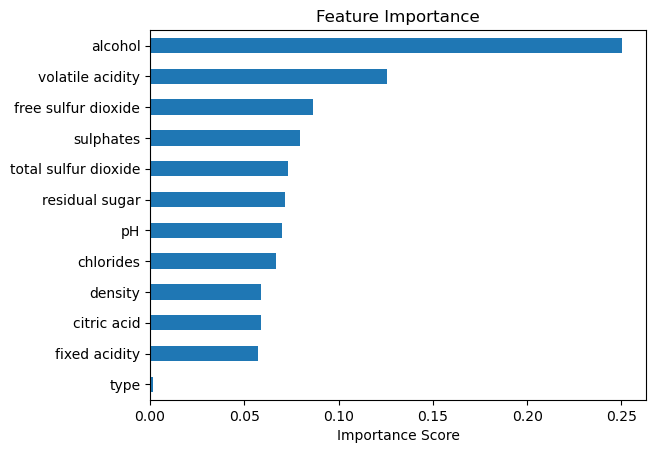

In [90]:
feature_importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

#### Actual vs Predicted Graph

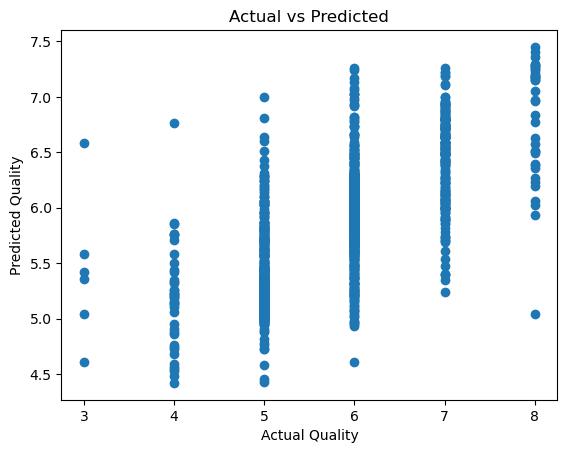

In [91]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted")
plt.show()

#### Residual Plot

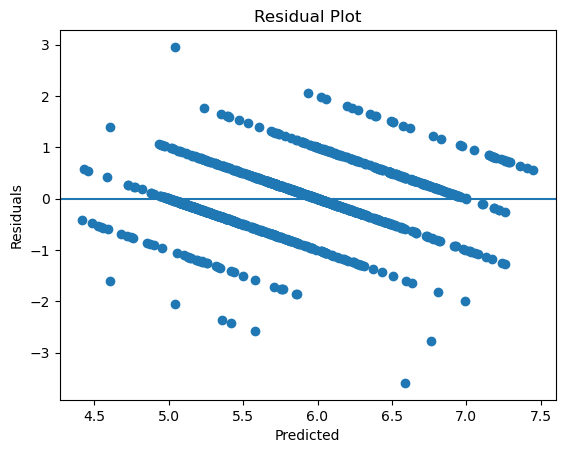

In [93]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [95]:
joblib.dump(voting_model, "wine_quality_model.pkl")

['wine_quality_model.pkl']

In [96]:
sample = [[7.4,0.70,0.00,1.9,0.076,11,34,0.9978,3.51,0.56,9.4,0]]
voting_model.predict(sample)

array([6.44743694])